# 02 · Construcción de Dataset V3 — 4 niveles de riesgo

**Objetivo:** construir un dataset con mayor granularidad usando la unidad de análisis **obra–participante/oferta**, manteniendo una etiqueta ordinal de **4 niveles de riesgo**.

La escala original de `RIESGO_OBRA` tiene 5 valores:

| Valor original | Descripción |
|---:|---|
| 0 | Sin riesgo |
| 1 | Bajamente riesgosa |
| 2 | Medianamente riesgosa |
| 3 | Altamente riesgosa |
| 4 | Extremadamente riesgosa |

En esta versión se fusionan los niveles 3 y 4:

| Nueva etiqueta | Nivel | Regla |
|---:|---|---|
| 0 | Sin riesgo | `RIESGO_OBRA == 0` |
| 1 | Bajo riesgo | `RIESGO_OBRA == 1` |
| 2 | Medio riesgo | `RIESGO_OBRA == 2` |
| 3 | Alto/Extremo riesgo | `RIESGO_OBRA >= 3` |

Esto evita una clase extremadamente pequeña y permite entrenar un baseline multiclase más defendible.


In [1]:
# ============================================================
# 0. Imports y configuración general
# ============================================================
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

RANDOM_STATE = 42

# Detectar raíz del proyecto de forma flexible
def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    candidates = [start, *start.parents]
    for c in candidates:
        if (c / 'data').exists() or (c / 'README.md').exists():
            return c
    return start

BASE = find_project_root()
DATA_RAW = BASE / 'data' / 'raw' / 'obra'
DATA_EXT = BASE / 'data' / 'external' / 'obra'
DATA_PROC = BASE / 'data' / 'processed'
REPORTS = BASE / 'reports' / 'figures'

# Fallback para cuando el notebook se ejecuta directamente en /mnt/data
if not DATA_RAW.exists() and not DATA_EXT.exists():
    DATA_RAW = Path.cwd()
    DATA_EXT = Path.cwd()

DATA_PROC.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

print('BASE:', BASE)
print('DATA_RAW:', DATA_RAW)
print('DATA_EXT:', DATA_EXT)
print('DATA_PROC:', DATA_PROC)
print('REPORTS:', REPORTS)


BASE: c:\IA_Investigacion\Deteccion_Corrupcion
DATA_RAW: c:\IA_Investigacion\Deteccion_Corrupcion\data\raw\obra
DATA_EXT: c:\IA_Investigacion\Deteccion_Corrupcion\data\external\obra
DATA_PROC: c:\IA_Investigacion\Deteccion_Corrupcion\data\processed
REPORTS: c:\IA_Investigacion\Deteccion_Corrupcion\reports\figures


## 1. Lectura robusta de archivos CSV

Los archivos pueden venir en `utf-8`, `latin1` o `cp1252`. Esta función intenta varias codificaciones y separadores para evitar fallos de ejecución en otra computadora.

In [2]:
# ============================================================
# 1. Funciones utilitarias
# ============================================================

OBRA_FILES = [
    'DS_DASH_Obra_1A.csv',
    'DS_DASH_Obra_2A_3A.csv',
    'DS_DASH_Obra_2B.csv',
    'DS_DASH_Obra_3B.csv',
    'DS_DASH_Obra_3C.csv',
    'DS_DASH_Obra_4A.csv',
    'DS_DASH_Obra_4B.csv',
    'DS_DASH_Obra_5A.csv',
]

def resolve_file(name: str) -> Path:
    candidates = [
        DATA_RAW / name,
        DATA_EXT / name,
        Path.cwd() / name,
        Path('/mnt/data') / name,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f'No se encontró {name}. Candidatos: {candidates}')

def read_csv_robust(path: Path) -> pd.DataFrame:
    encodings = ['utf-8', 'utf-8-sig', 'latin1', 'cp1252']
    seps = [',', ';', '|', '\t']
    last_error = None
    for enc in encodings:
        for sep in seps:
            try:
                df = pd.read_csv(path, encoding=enc, sep=sep)
                # Si queda una sola columna y el separador no es coma, quizá no es el sep correcto
                if df.shape[1] > 1:
                    df.columns = [str(c).strip() for c in df.columns]
                    return df
            except Exception as e:
                last_error = e
    raise RuntimeError(f'No se pudo leer {path}: {last_error}')

def clean_key(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().replace({'nan': np.nan, 'None': np.nan, '': np.nan})

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df

def as_numeric(series: pd.Series) -> pd.Series:
    # Limpia separadores comunes y convierte a número
    s = series.astype(str).str.replace(',', '', regex=False).str.replace(' ', '', regex=False)
    s = s.replace({'nan': np.nan, 'None': np.nan, '': np.nan})
    return pd.to_numeric(s, errors='coerce')


In [3]:
# ============================================================
# 2. Carga de archivos
# ============================================================
tablas = {}
summary = []

for fname in OBRA_FILES:
    path = resolve_file(fname)
    df = normalize_columns(read_csv_robust(path))
    tablas[fname] = df
    summary.append({
        'archivo': fname,
        'filas': len(df),
        'columnas': df.shape[1],
        'codigo_unico_nunique': df['CODIGO_UNICO'].nunique() if 'CODIGO_UNICO' in df.columns else np.nan,
        'identificador_obra_nunique': df['IDENTIFICADOR_OBRA'].nunique() if 'IDENTIFICADOR_OBRA' in df.columns else (df['Identificador_Obra'].nunique() if 'Identificador_Obra' in df.columns else np.nan),
    })

summary_df = pd.DataFrame(summary)
display(summary_df)
summary_df.to_csv(DATA_PROC / 'resumen_archivos_obra_v3.csv', index=False, encoding='utf-8')


,archivo,filas,columnas,codigo_unico_nunique,identificador_obra_nunique
0,DS_DASH_Obra_1A.csv,326,12,170.0,326.0
1,DS_DASH_Obra_2A_3A.csv,552,22,168.0,324.0
2,DS_DASH_Obra_2B.csv,1613,6,125.0,259.0
3,DS_DASH_Obra_3B.csv,5249,20,168.0,324.0
4,DS_DASH_Obra_3C.csv,5249,8,NaN,324.0
5,DS_DASH_Obra_4A.csv,326,9,170.0,NaN
6,DS_DASH_Obra_4B.csv,326,15,170.0,326.0
7,DS_DASH_Obra_5A.csv,634,15,170.0,326.0


## 2. Definición del target de 4 niveles

La tabla `DS_DASH_Obra_4B.csv` contiene `RIESGO_OBRA` y `RIESGO_DESCRIPCION_OBRA`. Esta información se usa **solo para construir la etiqueta**, no como variable predictora.

In [4]:
# ============================================================
# 3. Target ordinal de 4 niveles
# ============================================================
df_4b = tablas['DS_DASH_Obra_4B.csv'].copy()

required = ['IDENTIFICADOR_OBRA', 'RIESGO_OBRA']
missing = [c for c in required if c not in df_4b.columns]
if missing:
    raise ValueError(f'Faltan columnas en DS_DASH_Obra_4B.csv: {missing}')

df_4b['IDENTIFICADOR_OBRA'] = clean_key(df_4b['IDENTIFICADOR_OBRA'])
df_4b['RIESGO_OBRA'] = pd.to_numeric(df_4b['RIESGO_OBRA'], errors='coerce')

target = df_4b[['IDENTIFICADOR_OBRA', 'RIESGO_OBRA', 'RIESGO_DESCRIPCION_OBRA']].drop_duplicates('IDENTIFICADOR_OBRA').copy()
target = target.dropna(subset=['IDENTIFICADOR_OBRA', 'RIESGO_OBRA'])
target['RIESGO_OBRA'] = target['RIESGO_OBRA'].astype(int)

# 4 etiquetas: 0,1,2,3 donde 3 = alto + extremo
target['y_riesgo_4niveles'] = target['RIESGO_OBRA'].replace({0:0, 1:1, 2:2, 3:3, 4:3}).astype(int)

label_map = {
    0: 'Sin riesgo',
    1: 'Bajo riesgo',
    2: 'Medio riesgo',
    3: 'Alto/Extremo riesgo',
}
target['y_riesgo_4niveles_desc'] = target['y_riesgo_4niveles'].map(label_map)

print('Distribución original RIESGO_OBRA:')
display(target['RIESGO_OBRA'].value_counts().sort_index().rename('n').to_frame())

print('Distribución nueva y_riesgo_4niveles:')
dist_4 = target['y_riesgo_4niveles'].value_counts().sort_index().rename('n').to_frame()
dist_4['pct'] = (dist_4['n'] / dist_4['n'].sum()).round(4)
dist_4['descripcion'] = dist_4.index.map(label_map)
display(dist_4)

dist_4.to_csv(DATA_PROC / 'distribucion_target_4niveles_v3.csv', encoding='utf-8')


Distribución original RIESGO_OBRA:


,n
RIESGO_OBRA,
0,32
1,52
2,87
3,7
4,148


Distribución nueva y_riesgo_4niveles:


,n,pct,descripcion
y_riesgo_4niveles,,,
0,32,0.0982,Sin riesgo
1,52,0.1595,Bajo riesgo
2,87,0.2669,Medio riesgo
3,155,0.4755,Alto/Extremo riesgo


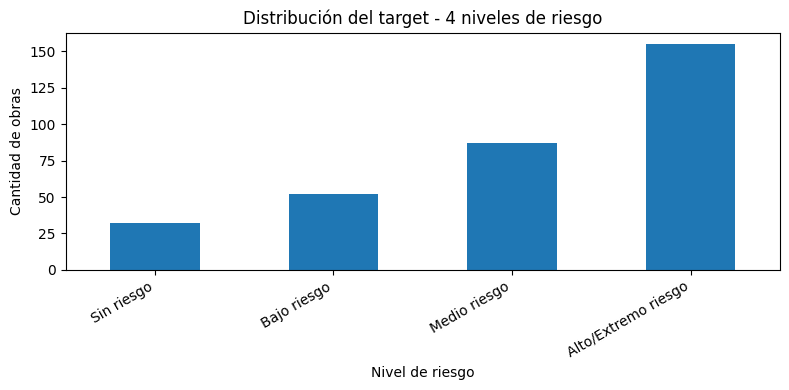

In [5]:
# Gráfico de distribución del target
ax = dist_4.set_index('descripcion')['n'].plot(kind='bar', figsize=(8,4), title='Distribución del target - 4 niveles de riesgo')
ax.set_xlabel('Nivel de riesgo')
ax.set_ylabel('Cantidad de obras')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(REPORTS / 'target_4niveles_distribucion.png', dpi=150)
plt.show()


## 3. Dataset V3: unidad de análisis obra–participante/oferta

Para aumentar la cantidad de registros sin inventar datos, se usa como base `DS_DASH_Obra_3B.csv`, que contiene múltiples registros por obra asociados a participantes, ganadores y contratos.

La etiqueta se une desde `DS_DASH_Obra_4B.csv` por `IDENTIFICADOR_OBRA`.

> Importante: al entrenar, el split se hace por grupos (`IDENTIFICADOR_OBRA`) para evitar que registros de una misma obra aparezcan simultáneamente en entrenamiento y prueba.

In [6]:
# ============================================================
# 4. Base granular: participantes / contratos / obra
# ============================================================
df_3b = tablas['DS_DASH_Obra_3B.csv'].copy()

if 'IDENTIFICADOR_OBRA' not in df_3b.columns:
    raise ValueError('DS_DASH_Obra_3B.csv no contiene IDENTIFICADOR_OBRA')

df_3b['IDENTIFICADOR_OBRA'] = clean_key(df_3b['IDENTIFICADOR_OBRA'])

# Join con target
dataset_v3 = df_3b.merge(
    target[['IDENTIFICADOR_OBRA', 'RIESGO_OBRA', 'RIESGO_DESCRIPCION_OBRA', 'y_riesgo_4niveles', 'y_riesgo_4niveles_desc']],
    on='IDENTIFICADOR_OBRA',
    how='inner'
)

print('Dataset V3 base 3B + target')
print('Filas:', dataset_v3.shape[0])
print('Columnas:', dataset_v3.shape[1])
print('Obras únicas:', dataset_v3['IDENTIFICADOR_OBRA'].nunique())
print('Distribución y_riesgo_4niveles:')
display(dataset_v3['y_riesgo_4niveles'].value_counts().sort_index().rename('n').to_frame())


Dataset V3 base 3B + target
Filas: 5249
Columnas: 24
Obras únicas: 324
Distribución y_riesgo_4niveles:


,n
y_riesgo_4niveles,
0,168
1,1287
2,1792
3,2002


## 4. Enriquecimiento con ofertas (`3C`)

`DS_DASH_Obra_3C.csv` contiene montos ofertados. Se integrará por identificador y, cuando existan columnas comunes como RUC o contrato, se intentará un merge más granular. Si no es posible, se agregan estadísticas por obra.

In [7]:
# ============================================================
# 5. Features desde 3C: ofertas
# ============================================================
df_3c = tablas['DS_DASH_Obra_3C.csv'].copy()

# Normalizar nombre de clave
if 'Identificador_Obra' in df_3c.columns and 'IDENTIFICADOR_OBRA' not in df_3c.columns:
    df_3c = df_3c.rename(columns={'Identificador_Obra': 'IDENTIFICADOR_OBRA'})

df_3c['IDENTIFICADOR_OBRA'] = clean_key(df_3c['IDENTIFICADOR_OBRA'])

# Detectar columna de monto ofertado
amount_candidates = [c for c in df_3c.columns if 'MONTO' in c.upper() and 'OFERT' in c.upper()]
print('Columnas candidatas de monto ofertado:', amount_candidates)

if amount_candidates:
    monto_col = amount_candidates[0]
    df_3c[monto_col] = as_numeric(df_3c[monto_col])
    offers_agg = df_3c.groupby('IDENTIFICADOR_OBRA').agg(
        n_ofertas=('IDENTIFICADOR_OBRA', 'count'),
        monto_ofertado_min=(monto_col, 'min'),
        monto_ofertado_max=(monto_col, 'max'),
        monto_ofertado_mean=(monto_col, 'mean'),
        monto_ofertado_median=(monto_col, 'median'),
        monto_ofertado_std=(monto_col, 'std'),
    ).reset_index()
    offers_agg['monto_ofertado_rango'] = offers_agg['monto_ofertado_max'] - offers_agg['monto_ofertado_min']
else:
    offers_agg = df_3c.groupby('IDENTIFICADOR_OBRA').size().reset_index(name='n_ofertas')

display(offers_agg.head())
print('Ofertas agregadas:', offers_agg.shape)

dataset_v3 = dataset_v3.merge(offers_agg, on='IDENTIFICADOR_OBRA', how='left')
print('Dataset V3 + ofertas:', dataset_v3.shape)


Columnas candidatas de monto ofertado: ['MONTO_OFERTADO']


,IDENTIFICADOR_OBRA,n_ofertas,monto_ofertado_min,monto_ofertado_max,monto_ofertado_mean,monto_ofertado_median,monto_ofertado_std,monto_ofertado_rango
0,2002060-2434-702592-2064311-19777,6,2235852.56,2480068.29,2.276555e+06,2235852.56,99700.654277,244215.73
1,2002210-8880-869397-2169938-826,14,0.00,332000.00,3.075133e+05,331016.99,88509.140993,332000.00
2,2002210-8880-870112-2169901-826,13,283575.23,290000.00,2.845637e+05,283575.23,2412.718344,6424.77
3,2026767-16256-709096-2067605-143536,20,2477357.77,2477357.77,2.477358e+06,2477357.77,0.000000,0.00
4,2027711-3876-682536-2050524-138320,23,3043955.25,3382172.49,3.073365e+06,3043955.25,97441.761873,338217.24


Ofertas agregadas: (324, 8)
Dataset V3 + ofertas: (5249, 31)


## 5. Enriquecimiento con variables agregadas por obra desde otras tablas

Se agregan conteos y estadísticas simples por `IDENTIFICADOR_OBRA`. Estas variables aprovechan la información repetida sin duplicar indebidamente el target.

In [8]:
# ============================================================
# 6. Agregados desde las demás tablas
# ============================================================

def get_keyed_df(fname: str) -> pd.DataFrame:
    df = tablas[fname].copy()
    if 'Identificador_Obra' in df.columns and 'IDENTIFICADOR_OBRA' not in df.columns:
        df = df.rename(columns={'Identificador_Obra': 'IDENTIFICADOR_OBRA'})
    if 'IDENTIFICADOR_OBRA' not in df.columns:
        return pd.DataFrame()
    df['IDENTIFICADOR_OBRA'] = clean_key(df['IDENTIFICADOR_OBRA'])
    return df

def basic_agg_by_obra(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    if df.empty or 'IDENTIFICADOR_OBRA' not in df.columns:
        return pd.DataFrame()
    out = df.groupby('IDENTIFICADOR_OBRA').size().reset_index(name=f'{prefix}_n_registros')
    # Nunique para columnas categóricas/código relevantes
    for col in df.columns:
        u = col.upper()
        if col == 'IDENTIFICADOR_OBRA':
            continue
        if any(token in u for token in ['RUC', 'CONTRATO', 'PROCESO', 'COMITE', 'MIEMBRO', 'EMPRESA', 'PARTICIPANTE', 'GANADOR']):
            try:
                tmp = df.groupby('IDENTIFICADOR_OBRA')[col].nunique(dropna=True).reset_index(name=f'{prefix}_nunique_{col}')
                out = out.merge(tmp, on='IDENTIFICADOR_OBRA', how='left')
            except Exception:
                pass
    return out

for fname, prefix in [
    ('DS_DASH_Obra_1A.csv', 'obra_1a'),
    ('DS_DASH_Obra_2A_3A.csv', 'obra_2a3a'),
    ('DS_DASH_Obra_2B.csv', 'obra_2b'),
    ('DS_DASH_Obra_4A.csv', 'obra_4a'),
    ('DS_DASH_Obra_5A.csv', 'obra_5a'),
]:
    dfx = get_keyed_df(fname)
    agg = basic_agg_by_obra(dfx, prefix)
    if not agg.empty:
        print(fname, agg.shape)
        dataset_v3 = dataset_v3.merge(agg, on='IDENTIFICADOR_OBRA', how='left')

print('Dataset V3 enriquecido:', dataset_v3.shape)


DS_DASH_Obra_1A.csv (326, 4)
DS_DASH_Obra_2A_3A.csv (324, 10)
DS_DASH_Obra_2B.csv (259, 5)
DS_DASH_Obra_5A.csv (326, 2)
Dataset V3 enriquecido: (5249, 48)


## 6. Control de leakage y limpieza para modelado

Se eliminan columnas que contienen directamente la etiqueta o texto descriptivo del riesgo. También se eliminan columnas con 100% de nulos o constantes.

In [9]:
# ============================================================
# 7. Limpieza y exclusión de leakage
# ============================================================

leakage_cols = [
    'RIESGO_OBRA',
    'RIESGO_DESCRIPCION_OBRA',
    'y_riesgo_4niveles_desc',
]

# Columnas descriptivas que podrían introducir identificadores fuertes o texto no controlado
possible_id_cols = []
for c in dataset_v3.columns:
    cu = c.upper()
    if any(token in cu for token in ['DESCRIPCION_RIESGO', 'RIESGO_DESCRIPCION']):
        possible_id_cols.append(c)

model_df = dataset_v3.drop(columns=list(set(leakage_cols + possible_id_cols)), errors='ignore').copy()

# Eliminar columnas 100% nulas
all_nan_cols = [c for c in model_df.columns if model_df[c].isna().all()]
model_df = model_df.drop(columns=all_nan_cols)

# Eliminar columnas constantes excepto claves/target
constant_cols = []
for c in model_df.columns:
    if c in ['IDENTIFICADOR_OBRA', 'y_riesgo_4niveles']:
        continue
    if model_df[c].nunique(dropna=True) <= 1:
        constant_cols.append(c)
model_df = model_df.drop(columns=constant_cols)

print('Columnas leakage excluidas:', leakage_cols)
print('Columnas 100% nulas eliminadas:', all_nan_cols)
print('Columnas constantes eliminadas:', constant_cols)
print('Shape final model_df:', model_df.shape)

print('Distribución final target:')
display(model_df['y_riesgo_4niveles'].value_counts().sort_index().rename('n').to_frame())


Columnas leakage excluidas: ['RIESGO_OBRA', 'RIESGO_DESCRIPCION_OBRA', 'y_riesgo_4niveles_desc']
Columnas 100% nulas eliminadas: []
Columnas constantes eliminadas: ['TIEMPO_ABSOLUCION_CONSULTAS', 'TIEMPO_PRESENTACION_OFERTAS', 'obra_1a_n_registros', 'obra_1a_nunique_PROCESO', 'obra_1a_nunique_OBJETO_PROCESO', 'obra_2a3a_nunique_PROCESO', 'obra_2a3a_nunique_OBJETO_PROCESO', 'obra_2a3a_nunique_CONVOCATORIA_PROCESO_GANADO', 'obra_2a3a_nunique_CODIGO_CONTRATO', 'obra_2a3a_nunique_NUMERO_CONTRATO', 'obra_2b_nunique_PROCESO']
Shape final model_df: (5249, 34)
Distribución final target:


,n
y_riesgo_4niveles,
0,168
1,1287
2,1792
3,2002


## 7. EDA mínimo del dataset V3

Este bloque genera estadísticas descriptivas, nulos y distribución de variables clave.

In [10]:
# ============================================================
# 8. EDA básico
# ============================================================
print('Shape:', model_df.shape)
print('Obras únicas:', model_df['IDENTIFICADOR_OBRA'].nunique())
print('Target:')
display(model_df['y_riesgo_4niveles'].value_counts().sort_index().rename('n').to_frame())

eda_nulls = pd.DataFrame({
    'columna': model_df.columns,
    'n_nulos': model_df.isna().sum().values,
    'pct_nulos': model_df.isna().mean().values,
    'n_unicos': model_df.nunique(dropna=False).values,
    'dtype': model_df.dtypes.astype(str).values,
}).sort_values('pct_nulos', ascending=False)

display(eda_nulls.head(25))
eda_nulls.to_csv(DATA_PROC / 'eda_nulos_dataset_obras_v3_4niveles.csv', index=False, encoding='utf-8')

num_cols_preview = model_df.select_dtypes(include='number').drop(columns=['y_riesgo_4niveles'], errors='ignore').columns.tolist()
display(model_df[num_cols_preview].describe().T.head(30))


Shape: (5249, 34)
Obras únicas: 324
Target:


,n
y_riesgo_4niveles,
0,168
1,1287
2,1792
3,2002


,columna,n_nulos,pct_nulos,n_unicos,dtype
31,obra_2b_nunique_DNI_MIEMBRO_COMITE,346,0.065917,11,float64
30,obra_2b_n_registros,346,0.065917,11,float64
32,obra_2b_nunique_NOMBRE_MIEMBRO_COMITE,346,0.065917,11,float64
24,monto_ofertado_std,72,0.013717,130,float64
1,SECTOR,0,0.000000,19,object
0,CODIGO_UNICO,0,0.000000,168,int64
2,DEPARTAMENTO,0,0.000000,23,object
3,NIVEL_GOBIERNO,0,0.000000,3,object
4,IDENTIFICADOR_OBRA,0,0.000000,324,object
5,PROCESO,0,0.000000,65,int64


,count,mean,std,min,25%,50%,75%,max
CODIGO_UNICO,5249.0,2.322645e+06,1.268025e+05,2.002060e+06,2.196451e+06,2.337745e+06,2.425240e+06,2.560253e+06
PROCESO,5249.0,1.674186e+01,2.184095e+01,1.000000e+00,3.000000e+00,1.100000e+01,2.500000e+01,5.390000e+02
CODIGO_OBRA,5249.0,1.230236e+05,5.362310e+04,8.260000e+02,1.089140e+05,1.293920e+05,1.354540e+05,5.053940e+05
CODIGO_RUC_GANADOR,5249.0,1.849961e+10,4.042668e+09,1.000105e+10,2.010858e+10,2.048788e+10,2.054770e+10,2.061056e+10
CONVOCATORIA_PROCESO_GANADO,5249.0,7.078780e+05,8.738859e+04,3.851710e+05,6.496830e+05,6.867730e+05,7.415700e+05,9.335750e+05
TotalProcesosParticipantes,5249.0,1.070909e+02,8.663968e+01,1.000000e+00,4.900000e+01,8.300000e+01,1.420000e+02,6.760000e+02
CODIGO_CONTRATO,5249.0,2.072538e+06,5.677250e+04,2.000154e+06,2.020868e+06,2.059355e+06,2.110390e+06,2.201544e+06
CODIGO_RUC_PARTICIPANTE,5249.0,2.020518e+10,1.252068e+10,5.528470e+05,2.011286e+10,2.050303e+10,2.055630e+10,9.900003e+10
n_ofertas,5249.0,9.040141e+01,9.944803e+01,1.000000e+00,1.400000e+01,4.200000e+01,1.720000e+02,2.870000e+02
monto_ofertado_min,5249.0,2.579372e+07,1.238045e+08,0.000000e+00,4.680247e+05,6.703129e+05,5.850000e+06,1.792432e+09


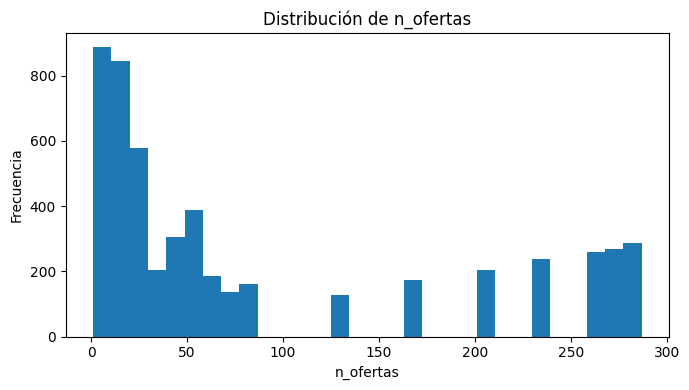

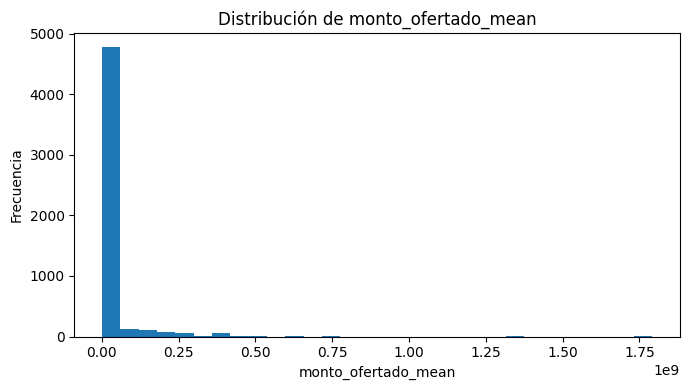

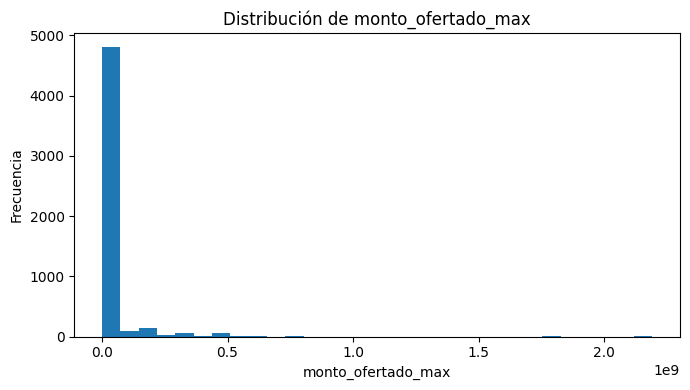

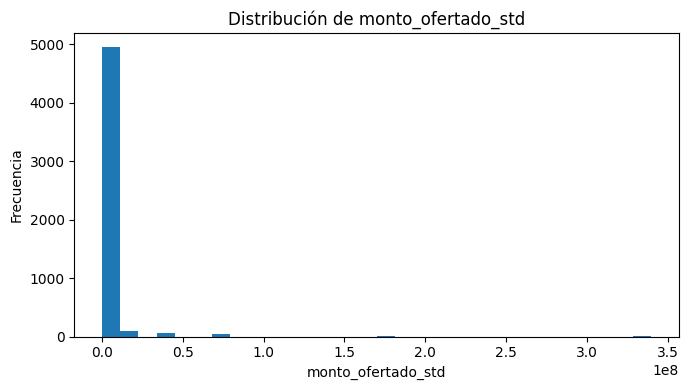

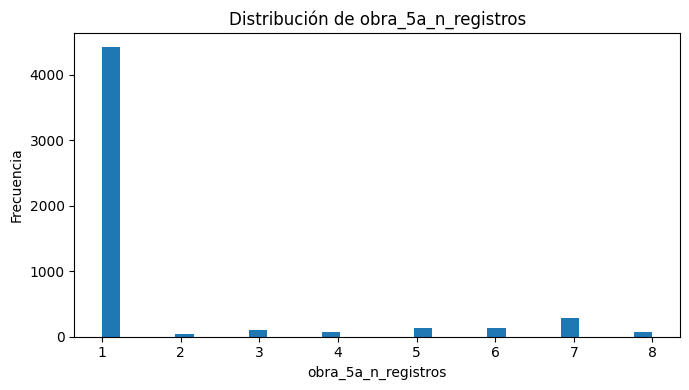

In [11]:
# Gráficos de variables numéricas clave si existen
plot_candidates = [
    'n_ofertas',
    'monto_ofertado_mean',
    'monto_ofertado_max',
    'monto_ofertado_std',
    'obra_3b_n_registros',
    'obra_5a_n_registros',
]

for col in plot_candidates:
    if col in model_df.columns:
        ax = model_df[col].dropna().plot(kind='hist', bins=30, figsize=(7,4), title=f'Distribución de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        plt.tight_layout()
        plt.savefig(REPORTS / f'dist_{col}.png', dpi=150)
        plt.show()


## 8. Guardado del dataset V3

Se generan salidas en Parquet y CSV para entrenamiento y trazabilidad.

In [12]:
# ============================================================
# 9. Guardar dataset
# ============================================================
out_parquet = DATA_PROC / 'dataset_obras_v3_4niveles_participante.parquet'
out_csv = DATA_PROC / 'dataset_obras_v3_4niveles_participante.csv'

model_df.to_parquet(out_parquet, index=False)
model_df.to_csv(out_csv, index=False, encoding='utf-8')

metadata = {
    'version': 'v3',
    'unidad_analisis': 'obra-participante/oferta',
    'target': 'y_riesgo_4niveles',
    'target_definicion': {
        '0': 'Sin riesgo: RIESGO_OBRA == 0',
        '1': 'Bajo riesgo: RIESGO_OBRA == 1',
        '2': 'Medio riesgo: RIESGO_OBRA == 2',
        '3': 'Alto/Extremo riesgo: RIESGO_OBRA >= 3',
    },
    'shape': list(model_df.shape),
    'n_obras_unicas': int(model_df['IDENTIFICADOR_OBRA'].nunique()),
    'distribucion_target': model_df['y_riesgo_4niveles'].value_counts().sort_index().astype(int).to_dict(),
    'archivos_fuente': OBRA_FILES,
    'leakage_cols_excluidas': leakage_cols,
    'all_nan_cols_eliminadas': all_nan_cols,
    'constant_cols_eliminadas': constant_cols,
}

(DATA_PROC / 'dataset_obras_v3_4niveles_participante_meta.json').write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding='utf-8'
)

print('Guardado:')
print(out_parquet)
print(out_csv)
print(DATA_PROC / 'dataset_obras_v3_4niveles_participante_meta.json')
metadata


Guardado:
c:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_obras_v3_4niveles_participante.parquet
c:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_obras_v3_4niveles_participante.csv
c:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_obras_v3_4niveles_participante_meta.json


{'version': 'v3',
 'unidad_analisis': 'obra-participante/oferta',
 'target': 'y_riesgo_4niveles',
 'target_definicion': {'0': 'Sin riesgo: RIESGO_OBRA == 0',
  '1': 'Bajo riesgo: RIESGO_OBRA == 1',
  '2': 'Medio riesgo: RIESGO_OBRA == 2',
  '3': 'Alto/Extremo riesgo: RIESGO_OBRA >= 3'},
 'shape': [5249, 34],
 'n_obras_unicas': 324,
 'distribucion_target': {0: 168, 1: 1287, 2: 1792, 3: 2002},
 'archivos_fuente': ['DS_DASH_Obra_1A.csv',
  'DS_DASH_Obra_2A_3A.csv',
  'DS_DASH_Obra_2B.csv',
  'DS_DASH_Obra_3B.csv',
  'DS_DASH_Obra_3C.csv',
  'DS_DASH_Obra_4A.csv',
  'DS_DASH_Obra_4B.csv',
  'DS_DASH_Obra_5A.csv'],
 'leakage_cols_excluidas': ['RIESGO_OBRA',
  'RIESGO_DESCRIPCION_OBRA',
  'y_riesgo_4niveles_desc'],
 'all_nan_cols_eliminadas': [],
 'constant_cols_eliminadas': ['TIEMPO_ABSOLUCION_CONSULTAS',
  'TIEMPO_PRESENTACION_OFERTAS',
  'obra_1a_n_registros',
  'obra_1a_nunique_PROCESO',
  'obra_1a_nunique_OBJETO_PROCESO',
  'obra_2a3a_nunique_PROCESO',
  'obra_2a3a_nunique_OBJETO_PROCES

## 9. Baseline multiclase con split por grupos

Como varias filas pertenecen a una misma obra, se usa `GroupShuffleSplit` con `IDENTIFICADOR_OBRA` como grupo. Esto evita leakage entre train y test.

Features numéricas: 23
Features categóricas: 9
Train filas: 4122 Test filas: 1127
Train obras únicas: 259 Test obras únicas: 65
Intersección de obras train/test: 0
Distribución train:


,n
y_riesgo_4niveles,
0,121
1,1248
2,1168
3,1585


Distribución test:


,n
y_riesgo_4niveles,
0,47
1,39
2,624
3,417


Métricas baseline multiclase:
{
  "accuracy": 0.4800354924578527,
  "balanced_accuracy": 0.3880886289331873,
  "macro_f1": 0.3552552112317867,
  "weighted_f1": 0.5272803214806385
}
Classification report:
                     precision    recall  f1-score   support

         Sin riesgo       0.13      0.19      0.15        47
        Bajo riesgo       0.02      0.23      0.04        39
       Medio riesgo       0.64      0.25      0.36       624
Alto/Extremo riesgo       0.85      0.88      0.87       417

           accuracy                           0.48      1127
          macro avg       0.41      0.39      0.36      1127
       weighted avg       0.67      0.48      0.53      1127



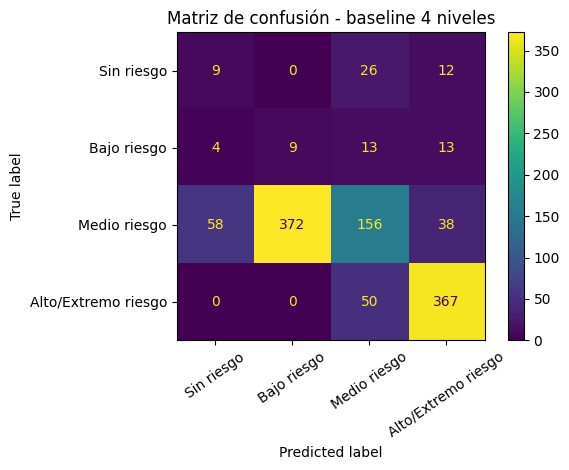

150

In [16]:
# ============================================================
# 10. Baseline multiclase 4 niveles
# ============================================================

TARGET = 'y_riesgo_4niveles'
GROUP_COL = 'IDENTIFICADOR_OBRA'

X = model_df.drop(columns=[TARGET], errors='ignore').copy()
y = model_df[TARGET].astype(int).copy()
groups = model_df[GROUP_COL].copy()

# No usar la clave como predictor directo
X_model = X.drop(columns=[GROUP_COL], errors='ignore')

# Separar columnas numéricas y categóricas
num_cols = X_model.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_model.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Features numéricas:', len(num_cols))
print('Features categóricas:', len(cat_cols))

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_model, y, groups=groups))

X_train, X_test = X_model.iloc[train_idx], X_model.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
g_train, g_test = groups.iloc[train_idx], groups.iloc[test_idx]

print('Train filas:', len(X_train), 'Test filas:', len(X_test))
print('Train obras únicas:', g_train.nunique(), 'Test obras únicas:', g_test.nunique())
print('Intersección de obras train/test:', len(set(g_train).intersection(set(g_test))))

print('Distribución train:')
display(y_train.value_counts().sort_index().rename('n').to_frame())
print('Distribución test:')
display(y_test.value_counts().sort_index().rename('n').to_frame())

pre = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), cat_cols),
])

clf = Pipeline([
    ('pre', pre),
    ('model', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        solver='saga',
        n_jobs=-1,
        random_state=42
    ))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

metrics = {
    'accuracy': float(accuracy_score(y_test, y_pred)),
    'balanced_accuracy': float(balanced_accuracy_score(y_test, y_pred)),
    'macro_f1': float(f1_score(y_test, y_pred, average='macro', zero_division=0)),
    'weighted_f1': float(f1_score(y_test, y_pred, average='weighted', zero_division=0)),
}

print('Métricas baseline multiclase:')
print(json.dumps(metrics, indent=2))

print('Classification report:')
print(classification_report(y_test, y_pred, zero_division=0, target_names=[label_map[i] for i in sorted(label_map)]))

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2,3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[label_map[i] for i in [0,1,2,3]])
disp.plot(values_format='d', xticks_rotation=35)
plt.title('Matriz de confusión - baseline 4 niveles')
plt.tight_layout()
plt.savefig(REPORTS / 'baseline_4niveles_confusion_matrix.png', dpi=150)
plt.show()

# Guardar métricas
(DATA_PROC / 'baseline_4niveles_metrics.json').write_text(json.dumps(metrics, indent=2), encoding='utf-8')


## 10. Riesgos identificados

**Leakage:**
- `RIESGO_OBRA` y `RIESGO_DESCRIPCION_OBRA` se usan solo para construir el target y se eliminan del entrenamiento.
- Se evita usar `IDENTIFICADOR_OBRA` como predictor directo.
- El split se realiza por grupos para que una obra no aparezca a la vez en entrenamiento y prueba.

**Desbalance:**
- La escala original tenía una clase `3` con muy pocos casos.
- Por eso se fusionan `3` y `4` en una sola categoría: `Alto/Extremo riesgo`.

**Drift:**
- Pueden existir cambios normativos, operativos o de registro entre periodos.
- En siguientes versiones debe validarse desempeño por año, entidad, región y tipo de contratación.

**Limitación:**
- Aunque el dataset granular aumenta filas, las observaciones siguen agrupadas por obra. Por ello las métricas deben interpretarse como baseline experimental, no como resultado final de producción.

In [17]:
# Resumen final para mostrar en demo
print('================ RESUMEN V3 ================')
print('Unidad de análisis: obra-participante/oferta')
print('Filas finales:', model_df.shape[0])
print('Columnas finales:', model_df.shape[1])
print('Obras únicas:', model_df['IDENTIFICADOR_OBRA'].nunique())
print('Target: y_riesgo_4niveles')
print('Distribución target:')
print(model_df['y_riesgo_4niveles'].value_counts().sort_index())
print('Métricas baseline:')
print(metrics)
print('Archivos generados en:', DATA_PROC)
print('Figuras generadas en:', REPORTS)


================ RESUMEN V3 ================
Unidad de análisis: obra-participante/oferta
Filas finales: 5249
Columnas finales: 34
Obras únicas: 324
Target: y_riesgo_4niveles
Distribución target:
y_riesgo_4niveles
0     168
1    1287
2    1792
3    2002
Name: count, dtype: int64
Métricas baseline:
{'accuracy': 0.4800354924578527, 'balanced_accuracy': 0.3880886289331873, 'macro_f1': 0.3552552112317867, 'weighted_f1': 0.5272803214806385}
Archivos generados en: c:\IA_Investigacion\Deteccion_Corrupcion\data\processed
Figuras generadas en: c:\IA_Investigacion\Deteccion_Corrupcion\reports\figures
